## 1. Executive Summary

## 2. Narrative-Driven Analysis

## 3. Data Retrieval

All datasets used in this exploratory analysis were obtained using the official data retrieval script provided by the project sponsor:

https://github.com/TrilemmaFoundation/bitcoin-analytics-capstone-template/blob/main/data/download_data.py

The script was executed from the repository root using Anaconda Prompt, which downloads the sponsor-managed Google Drive folder and organizes all usable files into a local `data/` directory while preserving the original subfolder structure. Only approved file types (`.parquet`, `.csv`, `.md`) are retained.

To keep this notebook lightweight and fully deterministic, we do not re-run the download step here. Instead, we assume the data have already been retrieved once using the official pipeline and only verify the expected directory structure before proceeding with exploratory analysis.

In [11]:
import os
from pathlib import Path

# ---- Set repo root explicitly ----
REPO_ROOT = Path(r"C:\Users\chen5\Documents\bitcoin-analytics-capstone")
os.chdir(REPO_ROOT)

print("Current working directory:")
print(os.getcwd())

# ---- Define data path ----
DATA_DIR = REPO_ROOT / "data"
print("Data directory exists:", DATA_DIR.exists())

# ---- Dataset-specific paths ----
COINMETRICS_PATH = DATA_DIR / "Coin Metrics" / "coinmetrics_btc.csv"
POLYMARKET_DIR = DATA_DIR / "Polymarket"

print("Coin Metrics file exists:", COINMETRICS_PATH.exists())
print("Polymarket dir exists:", POLYMARKET_DIR.exists())


Current working directory:
C:\Users\chen5\Documents\bitcoin-analytics-capstone
Data directory exists: True
Coin Metrics file exists: True
Polymarket dir exists: True


## 4. General Overview

This section provides a high-level overview of the datasets used in this exploratory analysis. The goal is to validate coverage and basic structure before conducting focused exploration.

Two sponsor-provided data sources are used:

- **Coin Metrics**: Daily Bitcoin market and on-chain metrics  
- **Polymarket**: Prediction market data for finance- and politics-related events


### 4.1 Coin Metrics: Bitcoin Market Baseline & Structural Context

Bitcoin market and on-chain data are sourced from Coin Metrics, a widely used provider of standardized cryptocurrency metrics.

The dataset is reported at a daily cadence (UTC) and spans from **2009-01-03 to 2026-01-14**, covering the full history of Bitcoin across multiple market cycles.
At this stage, the objective is to validate **time coverage, continuity, and high-level structure**, rather than perform feature engineering or predictive analysis.

These checks establish the **baseline market structure** against which any external signal (e.g., prediction market activity) must demonstrate **incremental or orthogonal informational value.**


#### Data Loading & Basic Validation

In [12]:
import pandas as pd

btc_df = pd.read_csv(COINMETRICS_PATH)
btc_df["time"] = pd.to_datetime(btc_df["time"])

print(
    "Rows:", btc_df.shape[0],
    "| Columns:", btc_df.shape[1],
    "| Missing days:",
    len(
        pd.date_range(
            btc_df["time"].min(),
            btc_df["time"].max(),
            freq="D"
        ).difference(btc_df["time"])
    )
)


Rows: 6221 | Columns: 32 | Missing days: 0


**Key checks:**

- The dataset contains 6,221 daily observations  
- The time index is continuous, with no missing calendar days  
- Columns cover price, market capitalization, network activity, and exchange flows  

**Note:** While the date index is fully continuous, some individual metrics contain missing values in early Bitcoin history. Summary statistics are therefore computed column-wise after dropping NaNs.

This confirms that the Coin Metrics data are complete and suitable for downstream exploratory analysis.These checks confirm that the Coin Metrics dataset provides a complete and temporally coherent baseline suitable for downstream exploratory analysis.

#### Value Ranges & Sanity Checks

In [22]:
btc_df[["PriceUSD", "TxCnt", "HashRate"]].describe().round(2)

,PriceUSD,TxCnt,HashRate
count,5659.00,6220.00,6.214000e+03
mean,19809.99,208414.23,1.514551e+08
std,29699.08,170293.82,2.634492e+08
min,0.05,0.00,0.000000e+00
25%,260.58,47152.50,6.284000e+01
50%,5728.35,224415.50,5.567322e+06
75%,28820.68,312607.50,1.652824e+08
max,124824.45,928131.00,1.305500e+09


The observed value ranges are consistent with known Bitcoin market behavior across early, mid, and recent history, further confirming structural validity.

#### Bitcoin Price History (Log Scale)

To establish long-horizon market context, we visualize Bitcoin’s full price history using a logarithmic scale. This highlights regime shifts and long-term growth while preserving early-period dynamics.

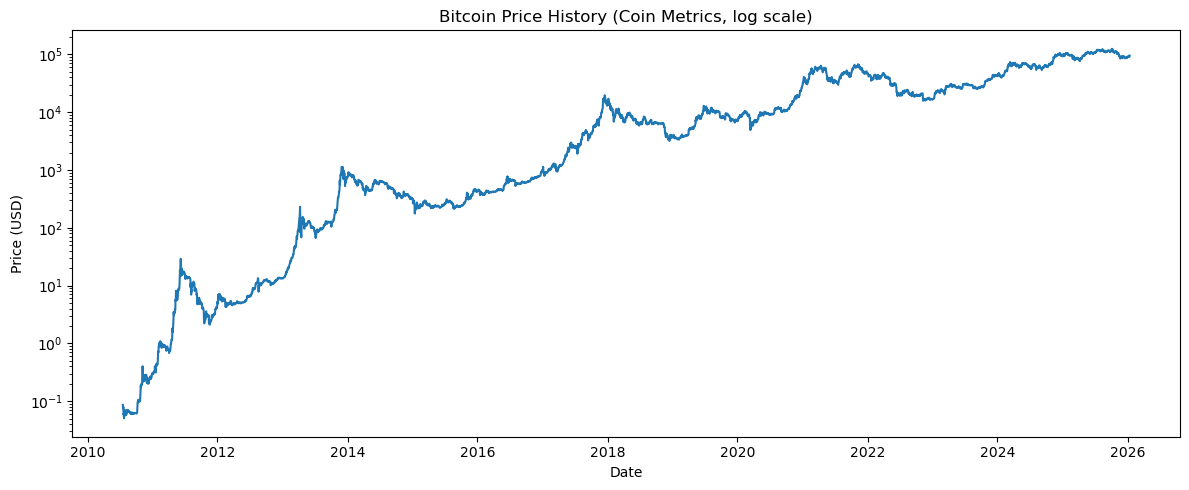

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(btc_df["time"], btc_df["PriceUSD"])
plt.yscale("log")
plt.title("Bitcoin Price History (Coin Metrics, log scale)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()


This visualization reveals Bitcoin’s characteristic multi-cycle structure, with periods of rapid expansion followed by drawdowns and consolidation.

The plot is included solely to establish regime context and is not used directly as a modeling signal.

#### High-Level Correlations Among Core Metrics

As a final structural check, we examine correlations among a small set of core market and network variables. This step provides descriptive context rather than causal inference.


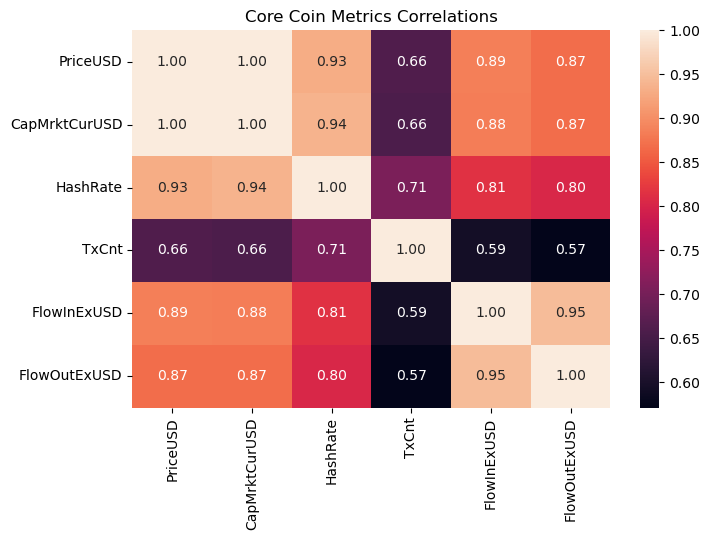

In [15]:
import seaborn as sns

core_cols = [
    "PriceUSD",
    "CapMrktCurUSD",
    "HashRate",
    "TxCnt",
    "FlowInExUSD",
    "FlowOutExUSD",
]
core_cols = [c for c in core_cols if c in btc_df.columns]

corr = btc_df[core_cols].dropna().corr()

plt.figure(figsize=(7.5, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Core Coin Metrics Correlations")
plt.tight_layout()
plt.show()


**Observations:**

- Price and market capitalization are nearly perfectly correlated, as expected  
- Hash rate exhibits strong association with long-term price levels  
- Exchange inflows and outflows are tightly correlated with each other  
- Transaction count shows weaker correlation, indicating distinct behavioral dynamics  

These relationships are noted strictly as background context for later, more targeted exploration.


**Section Takeaway**

The Coin Metrics dataset provides a complete, long-horizon view of Bitcoin’s market and on-chain behavior, with consistent daily coverage and well-defined core variables.

This establishes a reliable baseline against which the incremental value of prediction-market-derived signals can be evaluated in subsequent sections.

### 4.2 Polymarket: Prediction Market Data Validation

Polymarket data capture trading activity and price dynamics for prediction markets related to finance and politics. In this project, Polymarket serves as a complementary data source reflecting market-implied probabilities and participant behavior around macroeconomic, political, and Bitcoin-adjacent events.

The objective of this section is to validate **data availability, scale, and temporal integrity**, ensuring that Polymarket data can be safely aligned with Bitcoin market time series without introducing look-ahead bias.

#### Data Loading & Basic Validation

In [16]:
# ---- Load core Polymarket tables ----
pm_markets = pd.read_parquet(POLYMARKET_DIR / "finance_politics_markets.parquet")
pm_odds = pd.read_parquet(POLYMARKET_DIR / "finance_politics_odds_history.parquet")

# ---- Parse market-level timestamps ----
pm_markets["created_at"] = pd.to_datetime(pm_markets["created_at"])
pm_markets["end_date"] = pd.to_datetime(pm_markets["end_date"])

print("Markets table:", pm_markets.shape)
print("Odds history table:", pm_odds.shape)


Markets table: (78321, 10)
Odds history table: (2143181, 4)


The dataset consists of a large universe of individual markets and a high-frequency odds history, providing sufficient scale for aggregation and joint analysis

#### Structural Integrity Checks

In [17]:
print("Unique markets:", pm_markets["market_id"].nunique())
print("Unique events:", pm_markets["event_slug"].nunique())

pm_odds[["price"]].describe()


Unique markets: 78321
Unique events: 44033


,price
count,2.143181e+06
mean,5.000062e-01
std,3.909961e-01
min,5.000000e-04
25%,6.750000e-02
50%,5.000000e-01
75%,9.325000e-01
max,1.000000e+00


**Key observations**

- 78,321 unique markets across 44,033 events  
- Odds prices lie strictly within the [0,1] interval
- The distribution centers near 0.5, consistent with binary-outcome prediction markets

These checks confirm that the core numerical fields are well-formed.


#### Timestamp Anomaly Detection & Correction
Initial inspection of the odds history timestamps reveals an apparent anomaly:

In [25]:
print(
    "Raw odds time range:",
    pm_odds["timestamp"].min(),
    "→",
    pm_odds["timestamp"].max()
)


Raw odds time range: 1970-01-20 09:08:38.412000 → 1970-01-21 10:59:34.930000


Raw timestamps appear clustered around January 1970, inconsistent with Polymarket’s operational history.

This behavior indicates a **timestamp encoding issue**, rather than missing or corrupted data.

Further inspection shows that timestamps are stored as Unix epoch milliseconds but were materialized incorrectly. We correct this by reinterpreting the raw values numerically and converting them to UTC timestamps.

In [19]:
# ---- Fix odds timestamps (epoch milliseconds) ----
ts_ms = pd.to_numeric(pm_odds["timestamp"], errors="coerce")

pm_odds["timestamp_fixed"] = pd.to_datetime(ts_ms, unit="ms", utc=True)
pm_odds["date"] = pm_odds["timestamp_fixed"].dt.date

print(
    "Fixed odds time range:",
    pm_odds["timestamp_fixed"].min(),
    "→",
    pm_odds["timestamp_fixed"].max()
)
print("Unique days:", pm_odds["date"].nunique())


Fixed odds time range: 2023-01-24 00:00:12+00:00 → 2026-01-05 01:02:10+00:00
Unique days: 1066


**Result**

- Fixed odds time range: 2023-01-24 → 2026-01-05 (UTC)  
- Unique days covered: 1,066  

Resolving this issue is critical, as any misalignment would introduce **silent look-ahead bias** when joining prediction market data with daily Bitcoin metrics

#### Odds Update Density

As a final validation step, we examine the daily density of odds updates:

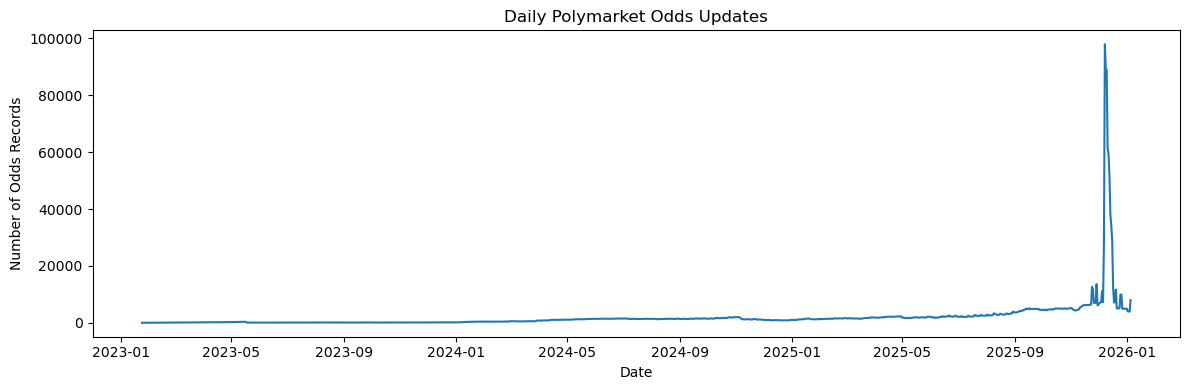

In [20]:
odds_daily = (
    pm_odds
    .groupby("date")
    .size()
)

plt.figure(figsize=(12, 4))
plt.plot(odds_daily.index, odds_daily.values)
plt.title("Daily Polymarket Odds Updates")
plt.xlabel("Date")
plt.ylabel("Number of Odds Records")
plt.tight_layout()
plt.show()


This confirms that Polymarket provides **dense, high-frequency activity** suitable for daily aggregation.
Daily aggregation therefore does not rely on sparse or intermittently sampled data, a necessary condition for regime-level signal construction.


**Section Takeaway**

The Polymarket dataset provides large-scale prediction market data with substantial market coverage, valid probability ranges, and high-frequency temporal resolution.

After resolving a critical timestamp encoding issue, the data align cleanly with Bitcoin market time series, enabling leakage-aware daily aggregation and joint exploratory analysis in subsequent sections.

## 5. EDA for Modeling Readiness

Having validated data integrity and temporal alignment, this section conducts targeted exploratory analysis to evaluate whether **Polymarket-derived signals can be aggregated into stable, interpretable daily features** and meaningfully aligned with Bitcoin market data.

Crucially, Polymarket signal construction is refined using a **high-liquidity filter (“smart money”)** to reduce thin-market noise and improve aggregation reliability.

The objective of this section is **not price prediction**, but to assess whether these signals are **structurally suitable conditioning inputs** for downstream modeling, particularly for dynamic, long-only accumulation strategies.

### 5.1 Refined Aggregation: Isolating “Smart Money”

Polymarket contains over 78,000 markets with highly uneven liquidity. Aggregating indiscriminately across all markets risks introducing microstructure noise from thinly traded contracts into daily features.

**Smart money (operational definition).**
In this notebook, “smart money” refers to a **high-liquidity subset of Polymarket markets**—specifically, the **top 100 markets by total trading volume**. This designation is purely operational: high-liquidity markets exhibit **denser updates, more continuous pricing, and more stable daily aggregates**, making them better suited for daily alignment with Bitcoin metrics.

Importantly, this terminology does **not** assert verified investor sophistication; it is a liquidity-based filtering convention.

**Feature construction logic:**
- **Filter:** Select the top 100 markets by total trading volume  
- **Aggregate:** Compute daily statistics using only this high-liquidity subset  

**Constructed features:**
- `smart_odds_updates`: Daily count of odds updates (attention / uncertainty proxy)  
- `smart_mean_price`: Daily average probability level (contextual signal)  
- `smart_price_std`: Dispersion of probabilities (belief divergence proxy)  

This approach prioritizes aggregation reliability and reduces noise from sparsely traded markets.


In [27]:
# ---- Filter for Top 100 Liquid Markets ----
top_volume_ids = pm_markets.nlargest(100, "volume")["market_id"]

# Filter the odds history to include ONLY these markets
pm_odds_filtered = pm_odds[pm_odds["market_id"].isin(top_volume_ids)]

# ---- Refined Daily Aggregation ----
pm_daily_refined = (
    pm_odds_filtered
    .groupby("date")
    .agg(
        smart_odds_updates=("price", "size"),
        smart_mean_price=("price", "mean"),
        smart_price_std=("price", "std")
    )
    .reset_index()
)

print("Refined Daily Features (Top 100 Markets):")
print(pm_daily_refined.head())
print("Shape:", pm_daily_refined.shape)


Refined Daily Features (Top 100 Markets):
         date  smart_odds_updates  smart_mean_price  smart_price_std
0  2024-01-05                  10               0.5         0.000000
1  2024-01-06                  18               0.5         0.423033
2  2024-01-07                  22               0.5         0.441671
3  2024-01-08                  22               0.5         0.445177
4  2024-01-09                  22               0.5         0.445677
Shape: (732, 4)


Across most days, **smart_mean_price remains close to 0.5**, reflecting binary outcome structures and cross-market averaging effects. Accordingly, mean price levels are treated as secondary context, while **activity- and dispersion-based features** are emphasized for downstream analysis.

### 5.2 Aligning with Bitcoin Data

The refined Polymarket features are aligned with daily Bitcoin market and on-chain metrics using an inner join on calendar dates. This ensures that all observations correspond to days with both Bitcoin data and high-liquidity prediction market activity.

In [28]:
# ---- Prepare daily Bitcoin table ----
btc_daily = (
    btc_df
    .assign(date=btc_df["time"].dt.date)
    .set_index("date")
    .sort_index()
)

# ---- Align Refined Datasets ----
pm_daily_idx = pm_daily_refined.set_index("date").sort_index()

aligned_df = (
    btc_daily
    .join(pm_daily_idx, how="inner")
    .sort_index()
)

print("Aligned dataset shape:", aligned_df.shape)

# Fill NaN for days where top markets might not have updates (unlikely but safe)
aligned_df = aligned_df.ffill()

aligned_df.head()


Aligned dataset shape: (732, 35)


,time,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,...,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d,smart_odds_updates,smart_mean_price,smart_price_std
date,,,,,,,,,,,,,,,,,,,,,
2024-01-05,2024-01-05,813324.0,52185685.0,1.704516e+09,1.704516e+09,138.0,1.983754,8.648562e+11,8.648256e+11,117.053818,...,1.959067e+07,1.613480e+06,7.122922e+10,2.074230e+07,416347.0,1025361.0,1.458810e+10,10,0.5,0.000000
2024-01-06,2024-01-06,808917.0,52182777.0,1.704603e+09,1.704603e+09,140.0,1.972627,8.604213e+11,8.603906e+11,85.704167,...,1.959155e+07,1.608179e+06,7.062797e+10,2.074241e+07,389306.0,917220.0,6.247901e+09,18,0.5,0.423033
2024-01-07,2024-01-07,713381.0,52185360.0,1.704691e+09,1.704691e+09,118.0,1.968589,8.590081e+11,8.589834e+11,76.090663,...,1.959229e+07,1.607342e+06,7.047262e+10,2.074250e+07,348435.0,813606.0,7.431340e+09,22,0.5,0.441671
2024-01-08,2024-01-08,756849.0,52192671.0,1.704773e+09,1.704773e+09,123.0,2.105200,9.205077e+11,9.204798e+11,128.016504,...,1.959306e+07,1.612735e+06,7.576842e+10,2.074260e+07,409400.0,900572.0,1.854234e+10,22,0.5,0.445177
2024-01-09,2024-01-09,902934.0,52162780.0,1.704863e+09,1.704863e+09,152.0,2.061112,9.029703e+11,9.029346e+11,110.412549,...,1.959401e+07,1.618416e+06,7.458308e+10,2.074272e+07,470829.0,1065162.0,1.915526e+10,22,0.5,0.445677


The resulting aligned dataset contains **732 daily observations and 35 features**, covering the period from early 2024 through early 2026.  

This table serves as the primary input for exploratory validation and subsequent modeling.

### 5.3 Visual Validation: Co-movement Analysis

To assess whether refined Polymarket activity exhibits meaningful co-movement with Bitcoin market dynamics, we visualize Bitcoin price and high-liquidity prediction market activity using a dual-axis time series plot:

- **Left axis:** Bitcoin price (log scale)  
- **Right axis:** `smart_odds_updates` (prediction market activity)


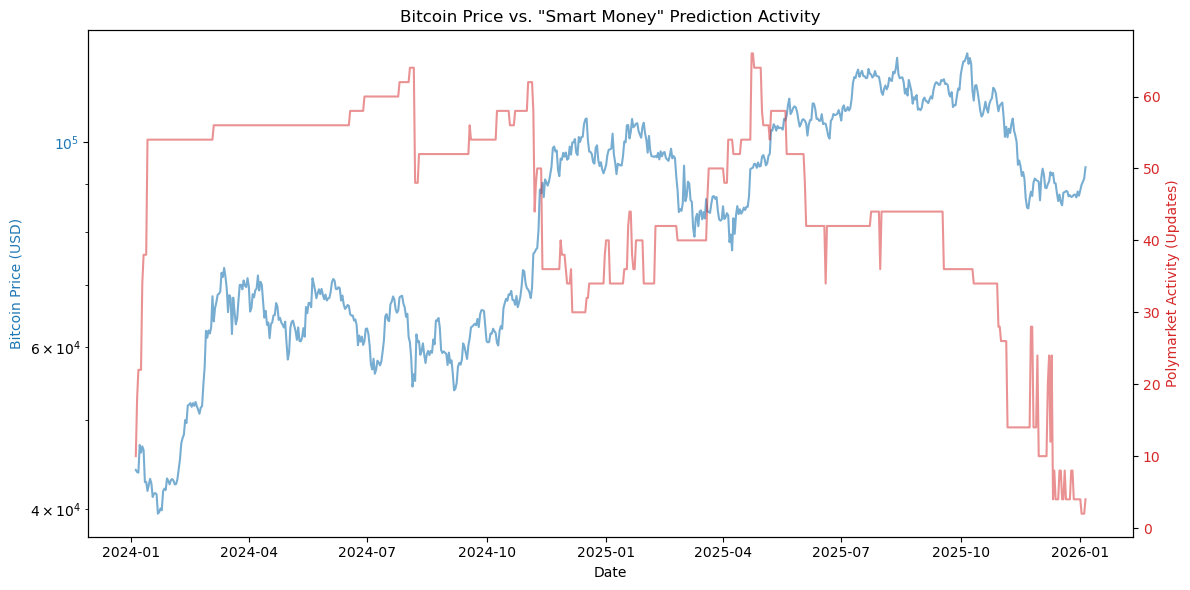

In [29]:
import matplotlib.pyplot as plt

# Create a Dual-Axis Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot BTC Price (Left Axis)
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Bitcoin Price (USD)', color=color)
ax1.plot(
    aligned_df.index,
    aligned_df['PriceUSD'],
    color=color,
    alpha=0.6,
    label='BTC Price'
)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

# Plot Smart Odds Updates (Right Axis)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Polymarket Activity (Updates)', color=color)
ax2.plot(
    aligned_df.index,
    aligned_df['smart_odds_updates'],
    color=color,
    alpha=0.5,
    label='Polymarket Activity'
)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Bitcoin Price vs. "Smart Money" Prediction Activity')
plt.tight_layout()
plt.show()


**Observation**

Periods of pronounced Bitcoin regime transitions are often accompanied by elevated smart money activity. Spikes in Polymarket participation frequently coincide with large price moves or structural shifts, suggesting that participation intensity may encode **market attention or uncertainty**, rather than short-term directional signals.


### 5.4 Correlation Check: Bitcoin Metrics vs. Refined Polymarket Signals

As a readiness check, we examine pairwise correlations between selected Bitcoin metrics and refined Polymarket features, alongside robustness tests designed to distinguish **regime-level structure from short-term noise**.



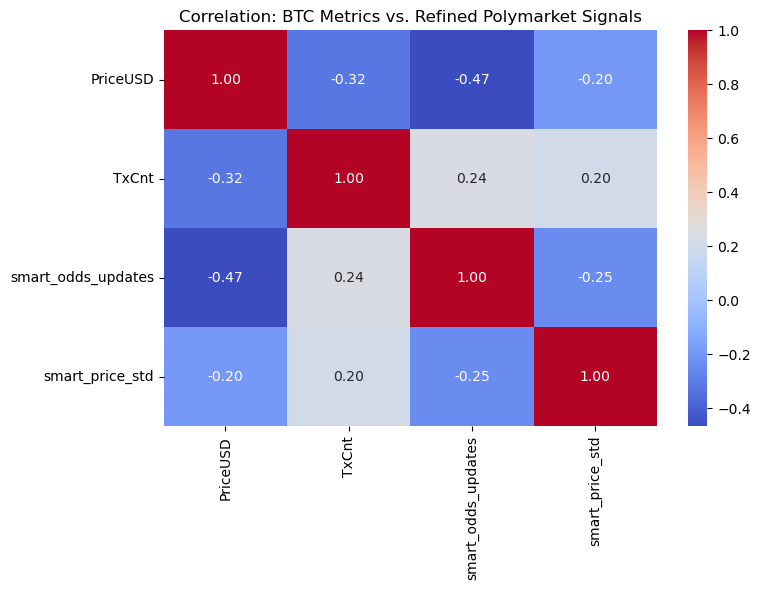

Robust Correlation (Returns vs Activity): 0.04545107235432393
Correlation (Activity vs Volatility): 0.04788559308049942


In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select key metrics for correlation
check_cols = [
    'PriceUSD',
    'TxCnt',
    'smart_odds_updates',
    'smart_price_std'
]

# Compute Correlation Matrix
corr_matrix = aligned_df[check_cols].corr()

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation: BTC Metrics vs. Refined Polymarket Signals")
plt.tight_layout()
plt.show()

# --- Robustness Check: Validating Signal Nature ---

# 1. Check correlation between Price Returns and Activity Levels
# (Tests if activity chases daily momentum)
corr_robust = aligned_df['PriceUSD'].pct_change().corr(aligned_df['smart_odds_updates'])
print(f"Robust Correlation (Returns vs Activity): {corr_robust}")

# 2. Check correlation between Activity and Volatility (Absolute Returns)
# (Tests if activity reacts to daily chop/noise)
corr_vol = aligned_df['smart_odds_updates'].corr(aligned_df['PriceUSD'].pct_change().abs())
print(f"Correlation (Activity vs Volatility): {corr_vol}")

Correlation (Log Price vs Activity): -0.46711418534557875


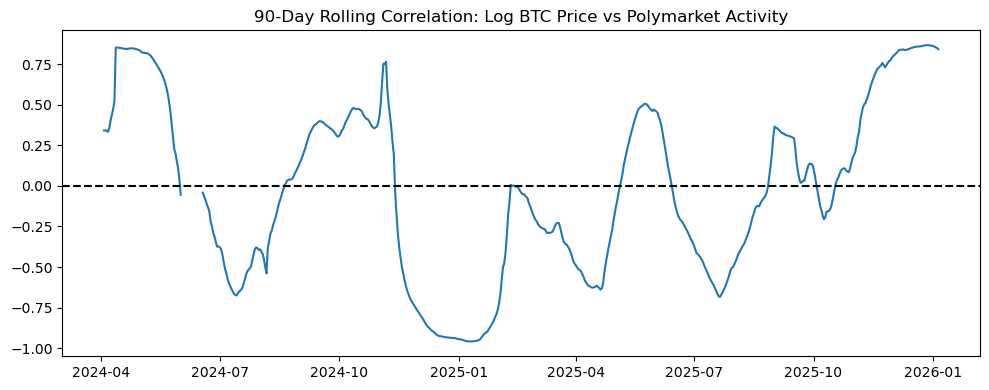

In [34]:
# --- Stationarity-Aware Robustness Check ---
# Use log price to reduce non-stationarity effects
import numpy as np

aligned_df["log_price"] = np.log(aligned_df["PriceUSD"])

corr_log = aligned_df["log_price"].corr(aligned_df["smart_odds_updates"])
print(f"Correlation (Log Price vs Activity): {corr_log}")

# Optional: rolling correlation (regime stability)
rolling_corr = (
    aligned_df["log_price"]
    .rolling(90)
    .corr(aligned_df["smart_odds_updates"])
)

plt.figure(figsize=(10, 4))
plt.plot(rolling_corr)
plt.axhline(0, color="black", linestyle="--")
plt.title("90-Day Rolling Correlation: Log BTC Price vs Polymarket Activity")
plt.tight_layout()
plt.show()


**Key findings:**
- `smart_odds_updates` shows a **moderate negative correlation (~ -0.47)** with Bitcoin price levels.
- Correlations with **daily returns (~0.045)** and **volatility (~0.048)** are near zero.
- Log-price correlations preserve the negative association, and rolling correlations indicate regime persistence rather than transient noise.

**Interpretation**

These results indicate that smart money activity is **not driven by short-term momentum or daily price fluctuations**. Instead, it behaves as a **low-frequency regime signal**, with elevated participation during lower-price environments.

Additionally, weak correlation with transaction count (TxCnt) suggests that Polymarket-derived features are **not redundant** with on-chain activity metrics


### 5.5 Exploratory Check: Accumulation Efficiency vs. Smart Money Activity

For accumulation strategies, the objective is not return prediction, but improving **satoshi-per-dollar efficiency** by allocating capital during relatively favorable price environments.

Using the **future 30-day minimum price drawdown** as a descriptive proxy for accumulation conditions, we examine its distribution across smart money activity regimes.

In [35]:
# ---- Accumulation Efficiency Proxy ----
aligned_df = aligned_df.copy()

# Future 30-day minimum price
aligned_df["future_min_30d"] = (
    aligned_df["PriceUSD"]
    .rolling(window=30, min_periods=1)
    .min()
    .shift(-30)
)

# Drawdown proxy (negative = better future buying opportunity)
aligned_df["future_drawdown_30d"] = (
    aligned_df["future_min_30d"] / aligned_df["PriceUSD"] - 1
)


In [36]:
# ---- Activity Regime Definition ----
aligned_df["activity_quantile"] = pd.qcut(
    aligned_df["smart_odds_updates"],
    q=3,
    labels=["Low Activity", "Medium Activity", "High Activity"]
)


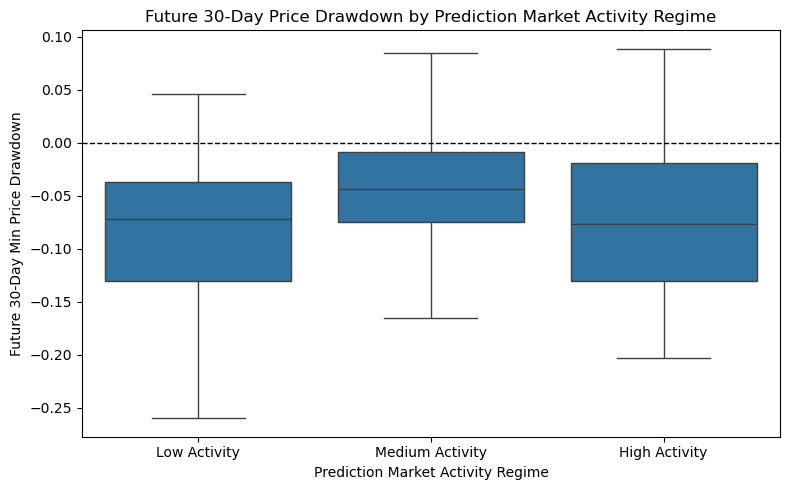

In [37]:

plot_df = aligned_df.dropna(
    subset=["future_drawdown_30d", "activity_quantile"]
)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=plot_df,
    x="activity_quantile",
    y="future_drawdown_30d",
    showfliers=False
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Future 30-Day Price Drawdown by Prediction Market Activity Regime")
plt.xlabel("Prediction Market Activity Regime")
plt.ylabel("Future 30-Day Min Price Drawdown")
plt.tight_layout()
plt.show()


**Observation**

Across all activity regimes, future 30-day drawdowns are predominantly negative, indicating that accumulation opportunities commonly exist regardless of activity level.

Importantly, **high smart money activity does not coincide with systematically worse future buying conditions**. The high-activity regime exhibits a drawdown distribution comparable to—and in the left tail slightly deeper than—low-activity periods.

**Interpretation**

This result does **not** imply price predictability. Rather, it suggests that smart money activity is **not harmful to accumulation efficiency** and is directionally aligned with environments where future price discounts are at least as likely as average.

From a dynamic DCA perspective, this supports the use of smart money activity as a **risk-aware allocation conditioner**, rather than a return forecasting signal.


## Section Takeaway

Through liquidity-based filtering, careful temporal alignment, and accumulation-oriented exploratory checks, Polymarket data can be transformed into **daily smart money features** that are structurally sound, economically interpretable, and aligned with long-only accumulation objectives.

While raw probability levels are largely uninformative in aggregate, **activity-based smart money signals function as a counter-cyclical regime filter**, supporting their inclusion as conditioning inputs in downstream dynamic DCA models.

## 6. Showcase Insight: Single-Market Lead–Lag & Conditional Structure (Illustrative)

This section presents an illustrative single-market case study using the highest-liquidity Polymarket contract (the “king” market) to probe whether market-implied probabilities exhibit short-horizon structure relative to Bitcoin price dynamics. This analysis is exploratory and optional: it is not required for the core accumulation feature set and is included to stress-test whether a single, clean probability series contains time-local signal beyond aggregate activity measures.

### 6.1 Directional Sentiment from the “King” Market

We focus on the single highest-volume Polymarket market during the sample period. The political content of the question is not used in interpretation; the probability series is treated strictly as a high-liquidity belief signal.


In [38]:
# ---- Identify the "King" Market ----
top_market_row = pm_markets.sort_values("volume", ascending=False).iloc[0]
top_market_id = top_market_row["market_id"]
market_question = top_market_row.get("question", "(question missing)")

print("market_id:", top_market_id)
print("question:", market_question)
print("volume:", top_market_row.get("volume"))

# ---- Load odds history for this market ----
market_odds = pm_odds.loc[pm_odds["market_id"] == top_market_id].copy()
print("rows in odds:", len(market_odds))
print("date range:", market_odds["date"].min(), "->", market_odds["date"].max())
print("unique token_id:", market_odds["token_id"].nunique())

# ---- Attach token outcomes (Yes/No) ----
if "pm_tokens" not in globals():
    pm_tokens = pd.read_parquet(POLYMARKET_DIR / "finance_politics_tokens.parquet")

market_odds = market_odds.merge(
    pm_tokens[["market_id", "token_id", "outcome"]],
    on=["market_id", "token_id"],
    how="left",
)

# ---- Extract daily "Yes" probability ----
target_odds = market_odds.loc[market_odds["outcome"] == "Yes"].copy()

target_daily = (
    target_odds
    .groupby("date")["price"]
    .mean()
    .rename("prediction_prob")
)

# ---- Align with BTC daily ----
analysis_df = btc_daily.join(target_daily, how="inner").sort_index()
print("Aligned data points:", len(analysis_df))


market_id: 253591
question: Will Donald Trump win the 2024 US Presidential Election?
volume: 1531479284.504353
rows in odds: 614
date range: 2024-01-05 -> 2024-11-06
unique token_id: 2
Aligned data points: 307


**Note.** This market is chosen solely because it is the most liquid contract on the platform during the sample period

### 6.2 Lead–Lag Cross-Correlation (Probability vs. BTC Log Returns) 
We examine cross-correlations between **daily changes in prediction-market probability** and **Bitcoin log returns** across short horizons.

**Methodology**

- BTC signal: daily log return of PriceUSD

- Polymarket signal: daily change in prediction_prob

- Lags: −10 to +10 days

- **Convention:** positive lag = probability leads price


peak_lag: -4
peak_corr: -0.08170108501387684
sanity n: 302
sanity corr at peak lag: -0.08170108501387684


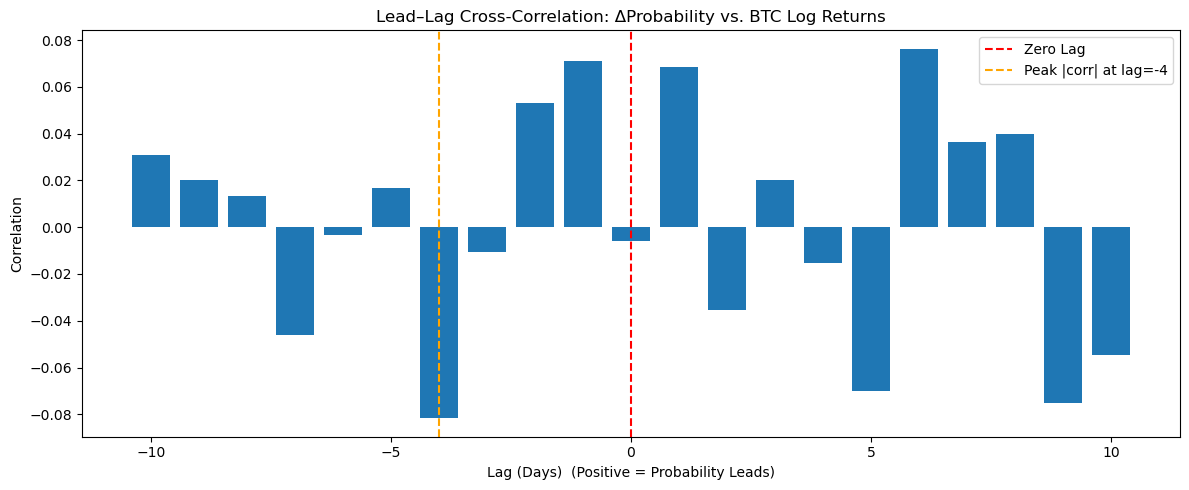

In [39]:
# ---- Compute daily changes ----
btc_lr = np.log(analysis_df["PriceUSD"]).diff()
prob_delta = analysis_df["prediction_prob"].diff()

# ---- Align valid indices ----
valid = btc_lr.dropna().index.intersection(prob_delta.dropna().index)
btc_lr = btc_lr.loc[valid]
prob_delta = prob_delta.loc[valid]

# ---- Cross-correlation by lag ----
lags = list(range(-10, 11))
corrs = [btc_lr.corr(prob_delta.shift(l)) for l in lags]

# Peak by absolute correlation (robust to sign)
peak_i = int(np.nanargmax(np.abs(corrs)))
peak_lag = lags[peak_i]
peak_corr = corrs[peak_i]

print("peak_lag:", peak_lag)
print("peak_corr:", peak_corr)

# ---- Sanity check at peak lag (pairwise) ----
tmp = pd.concat(
    [btc_lr.rename("btc_lr"), prob_delta.shift(peak_lag).rename("prob_shifted")],
    axis=1
).dropna()

print("sanity n:", len(tmp))
print("sanity corr at peak lag:", tmp["btc_lr"].corr(tmp["prob_shifted"]))

# ---- Plot (highlight peak) ----
plt.figure(figsize=(12, 5))
plt.bar(lags, corrs)
plt.axvline(0, color="red", linestyle="--", label="Zero Lag")
plt.axvline(peak_lag, color="orange", linestyle="--", label=f"Peak |corr| at lag={peak_lag}")
plt.title("Lead–Lag Cross-Correlation: ΔProbability vs. BTC Log Returns")
plt.xlabel("Lag (Days)  (Positive = Probability Leads)")
plt.ylabel("Correlation")
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation**

- The strongest (absolute) correlation occurs at a negative lag, i.e., BTC log returns tend to move first and probability changes follow ~4 days later.

- The magnitude is modest (|corr| ≈ 0.082), so this should be treated as a descriptive structure check rather than a predictive claim.

### 6.3 Conditional Forward Returns by Sentiment Regime

We examine Bitcoin 30-day forward returns conditional on high-conviction probability regimes.

n_total: 277
n_high: 27 n_low: 250
share_high_prob: 0.097


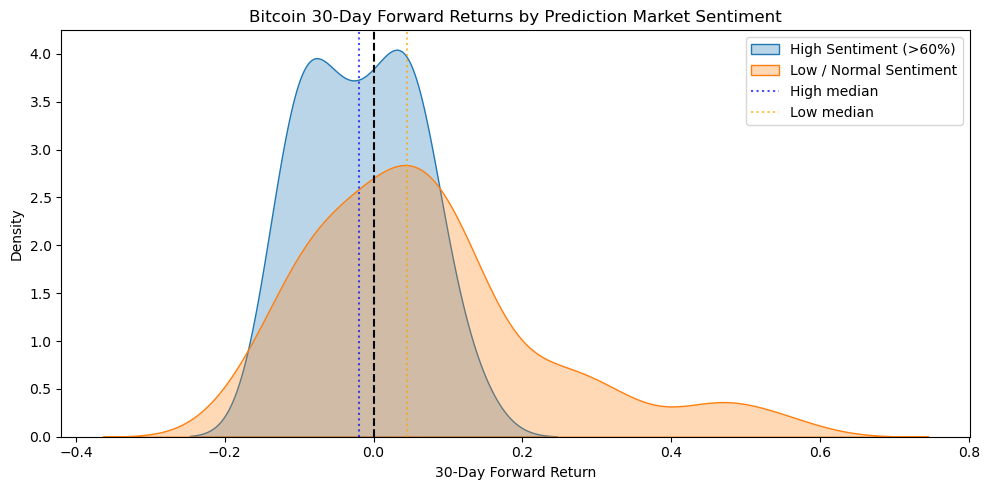

In [40]:
import seaborn as sns

# ---- Prepare KDE dataframe explicitly ----
kde_df = analysis_df[["prediction_prob", "PriceUSD"]].copy()

# 30-day forward return
kde_df["fwd_ret_30d"] = kde_df["PriceUSD"].pct_change(30).shift(-30)

# Drop NaNs
kde_df = kde_df.dropna(subset=["fwd_ret_30d", "prediction_prob"])

# Regime split
high = kde_df.loc[kde_df["prediction_prob"] > 0.60, "fwd_ret_30d"]
low  = kde_df.loc[kde_df["prediction_prob"] <= 0.60, "fwd_ret_30d"]

# ---- Sample size reporting ----
print("n_total:", len(kde_df))
print("n_high:", len(high), "n_low:", len(low))
print("share_high_prob:", round((kde_df["prediction_prob"] > 0.60).mean(), 3))

# ---- KDE plot ----
plt.figure(figsize=(10, 5))
sns.kdeplot(high, fill=True, alpha=0.3, label="High Sentiment (>60%)")
sns.kdeplot(low,  fill=True, alpha=0.3, label="Low / Normal Sentiment")

# Medians + zero line
plt.axvline(high.median(), color="blue", linestyle=":", alpha=0.7, label="High median")
plt.axvline(low.median(),  color="orange", linestyle=":", alpha=0.7, label="Low median")
plt.axvline(0, color="black", linestyle="--")

plt.title("Bitcoin 30-Day Forward Returns by Prediction Market Sentiment")
plt.xlabel("30-Day Forward Return")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


**Observation**

- The high-sentiment regime is a small subset (n_high ≈ 27, ~10% of observations), so interpretation should remain descriptive.

- The KDEs do not show a clear rightward shift in the high-sentiment distribution. Instead, the high-sentiment distribution appears more concentrated, while the low/normal regime exhibits wider dispersion and a heavier right tail.

**Interpretation**

This does not support a strong directional “high sentiment → higher average returns” conclusion. Instead, single-market sentiment appears to behave more like a market-state/attention condition than a reliable directional return signal. Importantly, elevated sentiment does not coincide with systematically worse forward returns, which is consistent with using sentiment as a conditioning feature rather than a return-forecasting input

**Section Takeaway**

Using the highest-liquidity Polymarket market as an illustrative case, we find that probability changes do not consistently lead BTC returns at short horizons. The peak cross-correlation occurs at a negative lag (≈ −4 days), indicating that probability updates tend to react after BTC moves rather than front-run them. A descriptive regime split (>60% probability) shows limited sample size (~10%) and no clear rightward shift in 30-day forward return distributions. Overall, this single-market signal is best treated as optional and illustrative, motivating aggregation-based features (Sections 4–5) rather than serving as a standalone predictive input.